In [1]:
import os
import errno
from collections import Counter
import teleGraph as tg
import matplotlib.pyplot as plt

### Auxilliary functions

In [2]:
import numpy as np
import pandas as pd
import json
import igraph as ig
import umap
import fastnode2vec as n2v
import warnings

In [110]:
## degree correlation for neutral undirected graph with degree distribution in G
def deg_corr_neutral(G, mode="all"):
    x = G.degree(mode=mode)
    return np.mean([i**2 for i in x]) / np.mean(x)

## Degree correlation functions

# undirected
def deg_corr(G):
    idx = {v: k for k, v in enumerate([i for i in set(G.degree())])}
    idx_inv = {k: v for k, v in enumerate(idx)}
    deg = G.degree()
    L = [[] for i in range(len(idx))]
    for v in G.vs():
        w = [deg[i] for i in G.neighbors(v)]
        L[idx[v.degree()]].extend(w)
    return {idx_inv[i]: np.mean(L[i]) for i in range(len(L))}


## k_nn^{mode1,mode2}(l) : average mode2-degree of out-neighbours of nodes with mode1-degree = l
def deg_corr_directed(G, mode1="all", mode2="all"):
    idx = {v: k for k, v in enumerate([i for i in set(G.degree(mode=mode1))])}
    idx_inv = {k: v for k, v in enumerate(idx)}
    deg = G.degree(mode=mode2)
    L = [[] for i in range(len(idx))]
    for v in G.vs():
        w = [deg[i] for i in G.neighbors(v, mode="out")]  ## do each link only once
        L[idx[v.degree(mode=mode1)]].extend(w)
    return {idx_inv[i]: np.mean(L[i]) for i in range(len(L)) if len(L[i]) > 0}
    
## Correlation exponent via linear regression (taking logs)
def corr_exp(G):
    ## compute knn's
    knn = deg_corr(G)
    # Fit the regression
    regressor = LinearRegression()
    x = [np.log(i) for i in knn.keys()]
    y = [np.log(i) for i in knn.values()]
    regressor.fit(np.array(x).reshape(-1, 1), y)
    return regressor.coef_[0]

## Asssortativity for directed graphs is only defined for the ('out','in') case in igraph
## Here is a general function for all cases
def assortativity_directed(G, mode1="out", mode2="in"):
    d1 = G.degree(mode=mode1)
    d2 = G.degree(mode=mode2)
    D = []
    for e in G.es:
        D.append([d1[e.source], d2[e.target]])
    D = np.array(D)
    avg1 = np.mean(D[:, 0])
    avg2 = np.mean(D[:, 1])
    S1 = sum([(v[0] - avg1) * (v[1] - avg2) for v in D])
    S2 = np.sqrt(sum([(v[0] - avg1) * (v[0] - avg1) for v in D]))
    S3 = np.sqrt(sum([(v[1] - avg2) * (v[1] - avg2) for v in D]))
    return S1 / (S2 * S3)


def corr_exp_directed(G, mode1="all", mode2="all"):
    ## compute knn's
    knn = deg_corr_directed(G, mode1, mode2)
    # Fit the regression
    regressor = LinearRegression()
    A = np.array(
        [[np.log(k), np.log(v)] for k, v in zip(knn.keys(), knn.values()) if k > 0 and v > 0]
    )
    # x = [np.log(i) for i in knn.keys()]
    # y = [np.log(i) for i in knn.values()]
    regressor.fit(A[:, 0].reshape(-1, 1), A[:, 1])
    return regressor.coef_[0]

In [4]:
def embedding_layout(g, dim = 4, p = 1.0, q = 1.0, walk_length = 80, window = 10, seed = 123):
    '''Embed graph for plotting purposes using the node2vec and UMAP combination 
        :param igraph.Graph g: graph to be embedded 
        :param int dim = 4: dimension of intermediate embedding (node2vec)
        :param float p = 1.0: The higher the value, the lower the probability to return to
                        the previous node during a walk.
        :param float q = 1.0: the higher the value, the lower the probability to return to
                        a node connected to a previous node during a walk. (node2vec)
        :param int walk_length = 80: length of the random walk (node2vec)
        :param int window = 10: size of the context window (node2vec)
        :param int seed = 123: random seed'''
    if sum([d == 0 for d in g.degree(loops = True)]) > 0:
        warnings.warn("Cannot generate embedding with isolated nodes and without loops")
        return None
    graph = n2v.Graph(g.to_tuple_list(), directed=False, weighted=False)
    nv = n2v.Node2Vec(graph, dim=dim, p = 1, q = 1, walk_length = walk_length, window = window, seed = seed)
    nv.train(epochs=20, verbose=False)
    Y = np.array([nv.wv[i] for i in range(len(nv.wv))])
    Y = umap.UMAP(random_state=seed, n_jobs=1).fit_transform(Y)
    ly = []
    for v in range(Y.shape[0]):
        ly.append((Y[v][0],Y[v][1]))
    return ly

def baseStats(graphs, names):
    '''Compute basic descriptive statistics of given graphs 
        :param list graphs: list of graphs (igraph.Graph objects)  
        :param list names: list of names (labels) of given graphs'''
    stats = []
    for (i,G) in enumerate(graphs):
        deg = G.degree(mode = "all")
        indeg = G.degree(mode = "in")
        outdeg = G.degree(mode = "out")
        stats.append([names[i],
        G.vcount(),
        G.ecount(),
        np.min(deg),
        np.min(indeg),
        np.min(outdeg), 
        np.mean(deg),
        np.mean(indeg),
        np.mean(outdeg),
        np.median(deg),
        np.median(indeg),
        np.median(outdeg),
        np.max(deg),
        np.max(indeg),
        np.max(outdeg),
        G.diameter(),
        np.max(G.connected_components().membership) + 1,
        G.connected_components().giant().vcount(),
        G.transitivity_undirected(mode="nan"),
        G.transitivity_avglocal_undirected(mode="nan"),
        ])
    return pd.DataFrame(stats,
    columns=[
        "network",
        "# nodes",
        "# edges",
        r"$\delta$",
        r"$\delta_{in}$",
        r"$\delta_{out}$",
        r"$\langle k\rangle$",
        r"$\langle k_{in}\rangle$",
        r"$\langle k_{out}\rangle$",
        r"median degree",
        r"median in degree",
        r"median out degree",
        r"$\Delta$",
        r"$\Delta_{in}$",
        r"$\Delta_{out}$",
        "diameter",
        "# (strong) components",
        "largest strongly connected component",
        r"$C_{glob}$",
        r"$C_{loc}$",
    ],).transpose()



In [5]:
def get_graph(edgelist, peers_data = None, leave_loops = True, verbose = True):
    if isinstance(edgelist, str):
        edgelist =  pd.read_csv(edgelist, sep = ';', encoding = 'utf=8')
    elif isinstance(peers_data, pd.DataFrame):
        edgelist = edgelist
    else:
        warnings.warn("edgelist is not correct type - it can be a DataFrame or directory")
        return None
    if isinstance(peers_data, str):
        filetype = peers_data.rsplit('.', 1)[-1]
        if filetype == 'json':
            with open(peers_data, 'r', encoding='utf-8') as j:
                peers_data = json.loads(j.read())
            peers_df = pd.DataFrame.from_dict(peers_data, orient='index', dtype=None, columns=None)
        else:
            peers_df =  pd.read_csv(peers_data, sep = ';', encoding = 'utf=8')
        peers_df.index = peers_df.index.astype('int64')
    elif isinstance(peers_data, pd.DataFrame):
        peers_df = peers_data
        peers_df.index = peers_df.index.astype('int64')
    else:
        peers_df = None
    G = ig.Graph.TupleList(edgelist[['source', 'target']].itertuples(index=False, name=None), 
                           directed=True, vertex_name_attr="id")
    if verbose:
        print("initial number of edges: ", len(G.es()))
        print("number of loops:", sum(G.is_loop()))
        print("initial number of nodes: ", len(G.vs()))
    #add weights and recombine parallel edges 
    G.es["weight"] = 1 
    G.simplify(multiple = True, loops = not leave_loops, combine_edges=sum)
    max_weight = np.max(G.es["weight"])
    G.es()["normalized_weight"] = [w / max_weight for w in G.es()["weight"]]
    #add parameters for plotting (color, size, shape)
    G.vs["color"] = 'gainsboro' 
    if isinstance(peers_df, pd.DataFrame):
        for node in G.vs():
            node_metadata = peers_df.loc[node["id"]]
            node["size"] = 3+4*(node_metadata["type"] == "Channel")
            node["shape"] = "circle" if node_metadata["type"] != "Channel" else "triangle-down"
    else:
        G.vs["size"] = 3
        G.vs["shape"] = "circle" 
    if verbose: #final summary
        print("Final number of edges: ", len(G.es()))
        print("Final number of loops:", sum(G.is_loop()))
        print("Final number of nodes: ", len(G.vs()))
    return G, peers_df
    

### Parameters

In [6]:
# Directory where you want to store scraped data: 
homedir = './poligon_project/results/'
utilspath = f'./poligon_project/'
datapath = f'./poligon_project/data/'
try:
    os.mkdir(homedir)
    os.mkdir(f'{homedir}/plots')
    os.mkdir(f'{homedir}/tables')
except OSError as e:
    if e.errno != errno.EEXIST:
        raise
respath = f'./{homedir}/'
filename = "telegraph_poligon"

In [7]:
#JSON file with channels classification:
channels_categories = 'channels_categories.json'
try:
    with open(utilspath + f'{channels_categories}', 'r', encoding='utf-8') as f:
        channels_categories = json.loads(f.read())
#if not provided, return simple user/channel/chat split:
except Exception as e:
    channels_categories = {0: "User", 1: "Channel", 2: "Chat"}

#JSON file with preliminarily classified channels
channels_classified = 'channels_classified.json'
try:
    with open(utilspath + f'{channels_classified}', 'r', encoding='utf-8') as f:
        channels_classified = json.loads(f.read())
#if not provided, return None:
except Exception as e:
    channels_classified = None

## Graphs loading + metadata

In [8]:
poliGraph, peers_df = get_graph(datapath + f'edgelist_full.csv', datapath + f'full_nodes_metadata.json', leave_loops = True)
for col in ['reactions', 'mentions', 'replies', 'forwards']:
    peers_df[col + '_given'] = [x['given'] for x in peers_df[col]]
    peers_df[col + '_received'] = [x['received'] for x in peers_df[col]]
    peers_df = peers_df.drop(col, axis=1)

initial number of edges:  382754
number of loops: 19824
initial number of nodes:  19507
Final number of edges:  101764
Final number of loops: 276
Final number of nodes:  19507


In [9]:
#full graph plotting 
plotting = True 
# embed graph for plotting purposes:
if plotting:
    ly_full = embedding_layout(poliGraph)
    ig.plot(poliGraph, edge_width = 0.051, edge_arrow_size = 0.07, layout = ly_full, bbox=(0, 0, 800, 800),
            target= respath + 'plots/poliGraph_full_plot.png')

### Components of Graph

In [10]:
print("nodes of degree zero in overall graph:",
    sum([d == 0 for d in poliGraph.degree(loops = False)]),)
disconnected_ids = [v['id'] for v in poliGraph.vs() if v.degree(loops = False) == 0]
isolated_users = peers_df[peers_df.index.isin(disconnected_ids)]  
#remove isolated nodes:
poliGraph.delete_vertices([v for v in poliGraph.vs() if v.degree(loops = False) == 0])
print("isolated users:\n")
isolated_users

nodes of degree zero in overall graph: 0
isolated users:



,type,username,active in,languages,no of messages,no of views,no of shares,reactions_given,reactions_received,mentions_given,mentions_received,replies_given,replies_received,forwards_given,forwards_received


In [11]:
## count the number of nodes in the giant component (weak connectivity)
print(poliGraph.connected_components(mode="weak").giant().vcount(),
    "out of",
    poliGraph.vcount(),
    "are in giant (weak) component",
)
print( poliGraph.connected_components(mode="strong").giant().vcount(),
    "out of",
    poliGraph.vcount(),
    "are in giant (strong) component",
)

conn_comp = poliGraph.connected_components(mode="weak").membership
comps = Counter(conn_comp) 
#number of components:
print(f'There are {len(comps)} components in graph')
# giant component:
giant = comps.most_common(1)[0][0]
#nodes outside giant component: 
disconnected_ids = []
components = []
for (i,v) in enumerate(poliGraph.vs["id"]):
    if conn_comp[i] != giant:
        disconnected_ids.append(v)
        components.append(conn_comp[i])
isolated_groups = peers_df[peers_df.index.isin(disconnected_ids)].copy()  
isolated_groups['component'] = components

19421 out of 19507 are in giant (weak) component
4889 out of 19507 are in giant (strong) component
There are 8 components in graph


#### Nodes and groups outside the giant component

In [12]:
for (comp, size) in comps.items():
    if comp != giant:
        component_members = isolated_groups[isolated_groups['component'] == comp]
        unique_channels = set(item for sublist in component_members['active in'] for item in sublist)
        for chan in unique_channels:
            channel_size = len(peers_df[[chan in chls for chls in peers_df['active in']]].index)
            members_in_comp = len(component_members[[chan in chls for chls in component_members['active in']]].index)
            if channel_size > members_in_comp:
                print(f'component {comp} contains {members_in_comp} isolated nodes from the group {chan}')
            elif channel_size == members_in_comp:
                print(f'component {comp} contains entire channel {chan} with {members_in_comp} members')
            else:
                print('Something is wrong!')  

component 1 contains entire channel @BelarusInLT with 7 members
component 2 contains entire channel @belvilnius with 7 members
component 3 contains 2 isolated nodes from the group @n_aujenoschat
component 4 contains entire channel @pribaltica with 4 members
component 5 contains entire channel @tarotjulija with 60 members
component 6 contains entire channel @tiesiogiaiisukrainos with 4 members
component 7 contains entire channel @zingeris with 2 members


### Giant component graph

In [13]:
#get only fully connected graph:
poliGraph, peers_df = get_graph(datapath + f'edgelist_full.csv', datapath + f'full_nodes_metadata.json', leave_loops = False)
poliGraphConn = poliGraph.connected_components(mode = "weak").giant().copy()
for col in ['reactions', 'mentions', 'replies', 'forwards']:
    peers_df[col + '_given'] = [x['given'] for x in peers_df[col]]
    peers_df[col + '_received'] = [x['received'] for x in peers_df[col]]
    peers_df = peers_df.drop(col, axis=1)

initial number of edges:  382754
number of loops: 19824
initial number of nodes:  19507
Final number of edges:  101488
Final number of loops: 0
Final number of nodes:  19507


In [14]:
#add category 
peers_df['category'] = [-1 if x == "Channel" else 0 for x in peers_df['type']]
peers_df['category'] = [channels_classified[x] if x in channels_classified else peers_df['category'].iloc[i] 
                        for i,x in enumerate(peers_df['username'])]

In [99]:
def label_prop(g, df):
    G = g.copy()
    G.vs['category'] = df['category'].copy().to_list()
    classified = G.vs['category']
    unlabeled_peers = df[(df['category'] == -1) | (df['category'] == 0)]
    labeled_peers = df[(df['category'] != -1) & (df['category'] != 0)]
    done = False
    while not done:
        previous_iter = classified.copy()
        for node in G.vs():
            c = Counter()
            for x in node.incident( mode = 'out'): 
                c[G.vs[x.target]['category']] += x['normalized_weight']
            for x in node.incident( mode = 'in'):
                c[G.vs[x.source]['category']] += x['normalized_weight']
            cls = c.most_common(1)[0][0]
            if cls != 0 and cls != -1:
                node['category'] = cls
        classified = G.vs['category']
        done = (previous_iter == classified)
    return classified

In [104]:
# Engagement rate df
dt = peers_df.copy()
dt['engagement rate'] = dt[['no of shares', 'reactions_received', 'mentions_received', 'forwards_received' , 'replies_received']].sum(axis = 1)/dt['no of views']
dt = dt.replace([np.inf, -np.inf], np.nan)
dt = dt.dropna()
dt = dt.sort_values('engagement rate', ascending = False)
#engagement for channels only 
dt2 = dt[dt['type'] == 'Channel']

In [105]:
# embed fully connected graph for plotting purposes:
ly = embedding_layout(poliGraphConn)

In [106]:
#full graph plotting 
plotting = True 
if plotting:
    ig.plot(poliGraphConn, edge_width = 0.051, edge_arrow_size = 0.07, layout = ly, bbox=(0, 0, 800, 800),
            target= respath + 'plots/poliGraph_plot.png')

In [ ]:
#pycairo                           1.27.0 to requirements

### Descriptive statistics of graphs

In [107]:
saving = False
stats_df = baseStats([poliGraph, poliGraphConn], ["poligon Graph", "poligon Graph Connected"])
if saving:
    stats_df.to_excel("tables/poligraph_basic_stats.xlsx", index=True, engine='openpyxl')
stats_df

,0,1
network,poligon Graph,poligon Graph Connected
# nodes,19507,19421
# edges,101488,101308
$\delta$,1,1
$\delta_{in}$,0,0
$\delta_{out}$,0,0
$\langle k\rangle$,10.40529,10.43283
$\langle k_{in}\rangle$,5.202645,5.216415
$\langle k_{out}\rangle$,5.202645,5.216415
median degree,3.0,3.0


In [108]:
print(f"percentage of nodes with in-degree equal to 0: {len([v for v in poliGraphConn.vs() if v.degree(mode = "in") == 0]) / len(poliGraphConn.vs()) * 100}%")
print(f"percentage of nodes with in-degree higher than 10: {len([v for v in poliGraphConn.vs() if v.degree(mode = "in") > 10 ]) 
                                                            / len(poliGraphConn.vs()) * 100}%")
print(f"percentage of nodes with in-degree higher than 100: {len([v for v in poliGraphConn.vs() if v.degree(mode = "in") > 100 ]) 
                                                            / len(poliGraphConn.vs()) * 100}%")

percentage of nodes with in-degree equal to 0: 51.68116986766902%
percentage of nodes with in-degree higher than 10: 9.08810050975748%
percentage of nodes with in-degree higher than 100: 0.6848257041346996%


In [118]:
respath + 'knn.png'

'././poligon_project/results//knn.png'

Assortativity: -0.13851691555096765


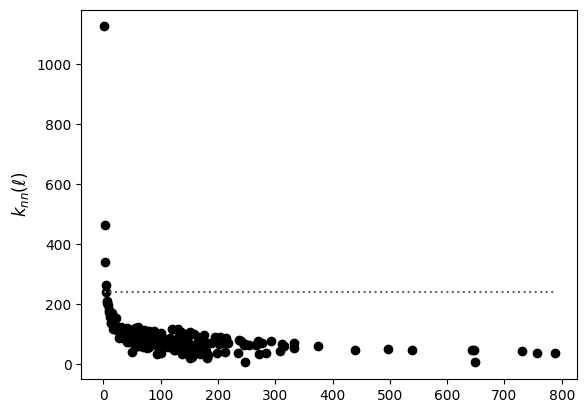

In [120]:
## OUT -- IN
knn = deg_corr_directed(poliGraphConn, "out", "in")
x = list(knn.keys())
y = list(knn.values())
r = deg_corr_neutral(poliGraphConn, "in")
plt.scatter(x, y, c="black")
plt.hlines(y=r, xmin=min(x), xmax=max(x), linestyles=":", color="dimgray")
plt.ylabel(r"$k_{nn}(\ell)$", fontsize=12);
plt.savefig('./poligon_project/results/plots/knn.png')
print(f"Assortativity: {assortativity_directed(poliGraphConn)}")

## @Kapciamiesciopoligonas graph

In [188]:
kGfull, _ = get_graph(datapath + f'kapcio_subgraph_edgelist.csv', peers_df)
print('\n')
kG, kapcio_peers = get_graph(datapath + f'kapcio_edgelist.csv', datapath + f'kapcio_nodes_metadata.json')
for col in ['reactions', 'mentions', 'replies', 'forwards']:
    kapcio_peers[col + '_given'] = [x['given'] for x in kapcio_peers[col]]
    kapcio_peers[col + '_received'] = [x['received'] for x in kapcio_peers[col]]
    kapcio_peers = kapcio_peers.drop(col, axis=1)

initial number of edges:  2975
number of loops: 33
initial number of nodes:  407
Final number of edges:  997
Final number of loops: 4
Final number of nodes:  407


initial number of edges:  929
number of loops: 14
initial number of nodes:  68
Final number of edges:  193
Final number of loops: 1
Final number of nodes:  68


#### impose @Kapciamiesciopoligonas on full graph

In [189]:
old_sizes = poliGraphConn.vs['size'].copy()
old_shapes = poliGraphConn.vs['shape'].copy()
poliGraphConn.vs['color'] = ['red' if idx in kG.vs['id'] else 'gainsboro' for idx in poliGraphConn.vs['id']]
poliGraphConn.vs['shape'] = ['square' if idx in kG.vs['id'] else 'circle' for idx in poliGraphConn.vs['id']]
poliGraphConn.vs['size'] = [7 if idx in kG.vs['id'] else 3 for idx in poliGraphConn.vs['id']]
ig.plot(poliGraphConn, edge_width = 0.051, edge_arrow_size = 0.07, layout = ly, bbox=(0, 0, 800, 800),
            target= respath + 'plots/poliGraph_kapcio.png')
poliGraphConn.vs['size'] = old_sizes
poliGraphConn.vs['shape'] = old_shapes
poliGraphConn.vs['color'] = 'gainsboro'

In [190]:
old_sizes = poliGraphConn.vs['size'].copy()
old_shapes = poliGraphConn.vs['shape'].copy()
poliGraphConn.vs['color'] = ['orange' if idx in kGfull.vs['id'] else 'gainsboro' for idx in poliGraphConn.vs['id']]
poliGraphConn.vs['color'] = ['red' if idx in kG.vs['id'] else poliGraphConn.vs['color'][i] 
                             for i, idx in enumerate(poliGraphConn.vs['id'])]
old_sizes = poliGraphConn.vs['size'].copy()
poliGraphConn.vs['shape'] = ['square' if idx in kGfull.vs['id'] else 'circle' for idx in poliGraphConn.vs['id']]
poliGraphConn.vs['size'] = [7 if idx in kGfull.vs['id'] else 3 for idx in poliGraphConn.vs['id']]
ig.plot(poliGraphConn, edge_width = 0.051, edge_arrow_size = 0.07, layout = ly, bbox=(0, 0, 800, 800),
            target= respath + 'plots/poliGraph_kapcio2.png')
poliGraphConn.vs['size'] = old_sizes
poliGraphConn.vs['shape'] = old_shapes
poliGraphConn.vs['color'] = 'gainsboro'

In [191]:
#full graph plotting 
plotting = True 
kapcio_ly = embedding_layout(kGfull)
# embed graph for plotting purposes:
if plotting:
    kG.vs['color'] = 'darkred'
    kG.vs['size'] = 7
    ig.plot(kG, edge_width = 0.051, edge_arrow_size = 0.07, layout = kapcio_ly, bbox=(0, 0, 800, 800),
            target= respath + 'plots/kapcioGraph_plot.png')
    kG.vs['color'] = 'gainsboro'
    kGfull.vs['color'] = ['darkred' if n['id'] in kG.vs['id'] else 'gainsboro' for n in kGfull.vs]
    kGfull.vs['size'] = [7 if n['id'] in kG.vs['id'] else 4 for n in kGfull.vs]
    ig.plot(kGfull, edge_width = 0.051, edge_arrow_size = 0.07, layout = kapcio_ly, bbox=(0, 0, 800, 800),
            target= respath + 'plots/kapcioGraph_full_plot.png')
    kGfull.vs['color'] = 'gainsboro'

In [192]:
lang_count = [Counter(x) for x in peers_df['languages']]
peers_df["most_common_lang"] = [x.most_common(1)[0][0] if x else '' for x in lang_count]
peers_df["lang_share"] = [x.most_common(1)[0][1] if x else 0 for x in lang_count]
peers_df["lang_share"] = peers_df["lang_share"]/ peers_df["no of messages"]
peers_df["no of groups"] = [len(x) for x in peers_df["active in"]]

In [227]:
xd = peers_df[[ 'username', 'no of groups',  'most_common_lang', 'lang_share', 'no of messages',
       'no of views', 'no of shares', 'reactions_given', 
       'mentions_given','replies_given', 'forwards_given', ]][peers_df['type'] == 'Channel']
xd[[idx in kGfull.vs['id'] for idx in xd.index]].sort_values('forwards_given', ascending=False).head(10)

,username,no of groups,most_common_lang,lang_share,no of messages,no of views,no of shares,reactions_given,mentions_given,replies_given,forwards_given
1550220813,@kochka_lv,5,rus_Cyrl,0.743448,9577,3415775,21396,0,3247,227,8680
2442080649,@tenipribaltiki,9,rus_Cyrl,0.746143,2722,2314852,19341,0,2053,52,1184
1790564310,@Kritinismastytojas,5,lit_Latn,0.457043,6844,2902138,32560,163,1158,93,984
1593350854,@n_aujienos,5,lit_Latn,0.969466,1572,237629,1348,0,1526,0,786
1991109430,@lita533,4,rus_Cyrl,0.757576,858,138877,1178,0,153,8,624
1717157579,@antifalivland,12,rus_Cyrl,0.888684,1626,40168321,65074,0,320,2,452
1150313433,@radiorlt,7,rus_Cyrl,0.864803,2611,5529359,25001,0,2127,3,249
1626736442,@liaudies,1,lit_Latn,0.830000,200,35858,81,0,9,0,198
1185696593,@seimusajudistesiasi,2,lit_Latn,1.000000,138,65803,382,0,130,0,138
1557403053,@alekseystefanov,12,rus_Cyrl,0.706503,569,3067259,19355,44,526,65,93


In [194]:
xd2 = xd[[idx in kG.vs['id'] for idx in xd.index]].sort_values('forwards_given', ascending=False)
xd2 = xd2[xd2['most_common_lang'] != '']
xd2['most_common_lang'].value_counts()/ sum(xd2['most_common_lang'].value_counts())

most_common_lang
lit_Latn    0.879310
rus_Cyrl    0.034483
azb_Arab    0.017241
epo_Latn    0.017241
pol_Latn    0.017241
ron_Latn    0.017241
min_Latn    0.017241
Name: count, dtype: float64

In [123]:
saving = False
stats_df = baseStats([kG, kGfull], ["kapcio Graph", "kapcio Graph Full"])
if saving:
    stats_df.to_excel("tables/poligraph_basic_stats.xlsx", index=True, engine='openpyxl')
stats_df

,0,1
network,kapcio Graph,kapcio Graph Full
# nodes,68,407
# edges,193,997
$\delta$,1,1
$\delta_{in}$,0,0
$\delta_{out}$,0,0
$\langle k\rangle$,5.676471,4.899263
$\langle k_{in}\rangle$,2.838235,2.449631
$\langle k_{out}\rangle$,2.838235,2.449631
median degree,3.0,2.0


## Poligon Mentions graph

In [195]:
mGfull, _ = get_graph(datapath + f'keywords_subgraph_edgelist.csv', peers_df)
print('\n')
mG, mention_peers = get_graph(datapath + f'keywords_edgelist.csv', datapath + f'keywords_nodes_metadata.json')

initial number of edges:  10935
number of loops: 123
initial number of nodes:  1123
Final number of edges:  4107
Final number of loops: 20
Final number of nodes:  1123


initial number of edges:  1598
number of loops: 86
initial number of nodes:  284
Final number of edges:  524
Final number of loops: 5
Final number of nodes:  284


#### impose poligon mentions on full graph

In [196]:
old_sizes = poliGraphConn.vs['size'].copy()
old_shapes = poliGraphConn.vs['shape'].copy()
poliGraphConn.vs['color'] = ['red' if idx in mG.vs['id'] else 'gainsboro' for idx in poliGraphConn.vs['id']]
poliGraphConn.vs['shape'] = ['square' if idx in mG.vs['id'] else 'circle' for idx in poliGraphConn.vs['id']]
poliGraphConn.vs['size'] = [7 if idx in kG.vs['id'] else 3 for idx in poliGraphConn.vs['id']]
ig.plot(poliGraphConn, edge_width = 0.051, edge_arrow_size = 0.07, layout = ly, bbox=(0, 0, 800, 800),
            target= respath + 'plots/poliGraph_mentions.png')
poliGraphConn.vs['size'] = old_sizes
poliGraphConn.vs['shape'] = old_shapes
poliGraphConn.vs['color'] = 'gainsboro'

In [197]:
old_sizes = poliGraphConn.vs['size'].copy()
old_shapes = poliGraphConn.vs['shape'].copy()
poliGraphConn.vs['color'] = ['orange' if idx in mGfull.vs['id'] else 'gainsboro' for idx in poliGraphConn.vs['id']]
poliGraphConn.vs['color'] = ['red' if idx in mG.vs['id'] else poliGraphConn.vs['color'][i] 
                             for i, idx in enumerate(poliGraphConn.vs['id'])]
old_sizes = poliGraphConn.vs['size'].copy()
poliGraphConn.vs['shape'] = ['square' if idx in mGfull.vs['id'] else 'circle' for idx in poliGraphConn.vs['id']]
poliGraphConn.vs['size'] = [7 if idx in mGfull.vs['id'] else 3 for idx in poliGraphConn.vs['id']]
ig.plot(poliGraphConn, edge_width = 0.051, edge_arrow_size = 0.07, layout = ly, bbox=(0, 0, 800, 800),
            target= respath + 'plots/poliGraph_mentions2.png')
poliGraphConn.vs['size'] = old_sizes
poliGraphConn.vs['shape'] = old_shapes
poliGraphConn.vs['color'] = 'gainsboro'

In [198]:
#full graph plotting 
plotting = True 
mention_ly = embedding_layout(mGfull)
# embed graph for plotting purposes:
if plotting:
    mG.vs['color'] = 'darkred'
    mG.vs['size'] = 7
    ig.plot(mG, edge_width = 0.051, edge_arrow_size = 0.07, layout = mention_ly, bbox=(0, 0, 800, 800),
            target= respath + 'plots/mGraph_plot.png')
    mG.vs['color'] = 'gainsboro'
    mGfull.vs['color'] = ['darkred' if n['id'] in mG.vs['id'] else 'gainsboro' for n in mGfull.vs]
    mGfull.vs['size'] = [7 if n['id'] in mG.vs['id'] else 4 for n in mGfull.vs]
    ig.plot(mGfull, edge_width = 0.051, edge_arrow_size = 0.07, layout = mention_ly, bbox=(0, 0, 800, 800),
            target= respath + 'plots/mGraph_full_plot.png')
    mGfull.vs['color'] = 'gainsboro'

In [225]:
saving = False
stats_df = baseStats([mG, mGfull], ["kapcio Graph", "kapcio Graph Full"])
if saving:
    stats_df.to_excel("tables/poligraph_basic_stats.xlsx", index=True, engine='openpyxl')
stats_df

,0,1
network,kapcio Graph,kapcio Graph Full
# nodes,284,1123
# edges,524,4107
$\delta$,1,1
$\delta_{in}$,0,0
$\delta_{out}$,0,0
$\langle k\rangle$,3.690141,7.314337
$\langle k_{in}\rangle$,1.84507,3.657168
$\langle k_{out}\rangle$,1.84507,3.657168
median degree,2.0,3.0


In [199]:
xd2 = xd[[idx in mG.vs['id'] for idx in xd.index]].sort_values('forwards_given', ascending=False)
xd2 = xd2[xd2['most_common_lang'] != '']
xd2['most_common_lang'].value_counts()/ sum(xd2['most_common_lang'].value_counts())

most_common_lang
lit_Latn    0.818681
rus_Cyrl    0.131868
eng_Latn    0.021978
min_Latn    0.010989
azb_Arab    0.005495
slv_Latn    0.005495
yue_Hant    0.005495
Name: count, dtype: float64

In [200]:
xd2 = xd[[idx in mGfull.vs['id'] for idx in xd.index]].sort_values('forwards_given', ascending=False)
xd2 = xd2[xd2['most_common_lang'] != '']
xd2['most_common_lang'].value_counts()/ sum(xd2['most_common_lang'].value_counts())

most_common_lang
lit_Latn    0.677193
rus_Cyrl    0.245614
min_Latn    0.025731
eng_Latn    0.024561
yue_Hant    0.003509
est_Latn    0.002339
swe_Latn    0.002339
deu_Latn    0.002339
azb_Arab    0.001170
kor_Hang    0.001170
nno_Latn    0.001170
pol_Latn    0.001170
epo_Latn    0.001170
ron_Latn    0.001170
ind_Latn    0.001170
ast_Latn    0.001170
bel_Cyrl    0.001170
ukr_Cyrl    0.001170
lvs_Latn    0.001170
hye_Armn    0.001170
ita_Latn    0.001170
slv_Latn    0.001170
Name: count, dtype: float64

In [205]:
channels_categories

{'0': 'user',
 '1': 'prorussian',
 '2': 'official_news',
 '3': 'nationalists',
 '4': 'proukrainian',
 '5': 'alternative_media',
 '6': 'conspiracy_theories',
 '7': 'local_news',
 '-1': 'not_classified'}

In [221]:
dt2['engagement rate'] = dt2['engagement rate'] * 100

In [211]:
dt2['category'] = [channels_categories[str(x)] for x in dt2['category']]
dt['category'] = [channels_categories[str(x)] for x in dt['category']]


In [213]:
dt2[['category', 'engagement rate']].groupby(["category"]).mean()

,engagement rate
category,
alternative_media,0.024917
conspiracy_theories,0.020212
local_news,0.014052
nationalists,0.038478
not_classified,0.024663
official_news,0.020256
prorussian,0.031167
proukrainian,0.011300


In [212]:
dt[['category', 'engagement rate']].groupby(["category"]).mean()

,engagement rate
category,
alternative_media,0.024917
conspiracy_theories,0.020212
local_news,0.014052
nationalists,0.038478
not_classified,0.024663
official_news,0.020256
prorussian,0.031167
proukrainian,0.011300
user,0.028433


In [223]:
dt2[[x  in kapcio_peers.index for x in dt2.index]][['category', 'engagement rate']].groupby(["category"]).mean()

,engagement rate
category,
alternative_media,3.874651
nationalists,4.184479
not_classified,2.985249


In [224]:
dt2[[x  in kGfull.vs['id'] for x in dt2.index]][['category', 'engagement rate']].groupby(["category"]).mean()

,engagement rate
category,
alternative_media,2.659861
conspiracy_theories,1.923898
nationalists,4.184479
not_classified,2.273348
official_news,1.368893


In [216]:
dt[[x  in mGfull.vs['id'] for x in dt.index]][['category', 'engagement rate']].groupby(["category"]).mean()

,engagement rate
category,
alternative_media,0.026599
conspiracy_theories,0.019239
local_news,0.013637
nationalists,0.041845
not_classified,0.027557
official_news,0.018096
prorussian,0.037225
proukrainian,0.015860
user,0.014595


In [219]:
dt2['engagement rate'].mean()

0.02404487909799151

In [220]:
dt2[dt2.index == 3137388250]

,type,username,active in,languages,no of messages,no of views,no of shares,reactions_given,reactions_received,mentions_given,mentions_received,replies_given,replies_received,forwards_given,forwards_received,category,engagement rate
3137388250,Channel,@Kapciamiesciopoligonas,"[@lita533, @ZoroKanalas, @neadeqatus, @n_aujen...","{'lit_Latn': 341, 'yue_Hant': 4, 'min_Latn': 1...",520,194909,1053,0,2680,314,515,14,704,14,140,not_classified,0.026125
